# 01 — D1 `rule_vix_threshold` (Reglas / Umbrales)

Baseline reactivo y **causal nativo**: regla sobre el NIVEL del VIX con **histéresis** (banda muerta τ_in/τ_out) + **dwell-time** mínimo, para evitar el flickering de un umbral simple. 2 estados: 0=calma, 1=crisis.

**Política de ventana**: el VIX existe desde **1990**, así que la feature se construye desde el panel crudo largo (no desde `features.parquet`, atado a 2007 por HYG). Así el walk-forward cubre **2008 y 2011** out-of-sample.

**Hipótesis CHECKPOINT 2 (D1)**: *capta las 4 crisis y, por reactividad, probablemente 2013 y 2018 que el HMM falló; su talón de Aquiles son los falsos positivos ante picos efímeros si NO lleva histéresis*. Verificamos al final.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import features as ft, evaluation as ev
from detectors.rule_vix_threshold import RuleVixThreshold

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('Panel crudo:', raw.shape, '|', raw.index.min().date(), '->', raw.index.max().date())
print('VIX primer dato válido:', raw['VIX'].first_valid_index().date())

Panel crudo: (10591, 9) | 1985-01-02 -> 2026-06-16
VIX primer dato válido: 1990-01-02


## 1. Feature causal de VIX (histórico largo) + retorno del S&P 500

- `VIX_level_z`: nivel del VIX z-scoreado de forma **causal** (expanding, `features.causal_zscore`). En t solo usa media/std de datos ≤ t.
- `SP500_ret`: retorno log del S&P 500, reindexado a la feature. Sirve para (a) el **etiquetado económico** de estados (0=calma..1=crisis) y (b) como `market_returns` del evaluador.

El panel arranca cuando `VIX_level_z` tiene suficientes observaciones (`min_periods`), es decir ~1990.

In [2]:
vix = raw['VIX'].dropna()                       # desde 1990
vix_z = ft.causal_zscore(vix.rename('VIX_level'))
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')

X = pd.DataFrame({
    'VIX_level_z': vix_z,
    'SP500_ret': spx_ret.reindex(vix_z.index),
}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
X.head(3)

X (histórico largo): (9010, 2) | 1990-03-27 -> 2026-06-12


,VIX_level_z,SP500_ret
date,,
1990-03-27,-0.515166,0.011397
1990-03-28,-0.987416,0.001463
1990-03-29,-1.464789,-0.003544


**Verificación de causalidad** de la feature: truncar la entrada en una fecha y recomputar el z-score debe dar exactamente los mismos valores que computarlo sobre la serie completa y recortar. El pasado no cambia al añadir futuro.

In [3]:
cut = '2015-01-01'
full = ft.causal_zscore(vix.rename('VIX_level'))
trunc = ft.causal_zscore(vix.loc[:cut].rename('VIX_level'))
idx = trunc.index.intersection(full.index); idx = idx[idx <= pd.Timestamp(cut)]
max_diff = float((full.loc[idx] - trunc.loc[idx]).abs().max())
print(f'max_abs_diff hasta {cut}: {max_diff:.2e}  ->  causal_ok = {max_diff < 1e-9}')
assert max_diff < 1e-9, 'La feature VIX_level_z NO es causal'

max_abs_diff hasta 2015-01-01: 0.00e+00  ->  causal_ok = True


## 2. El detector D1 y sus umbrales causales

`RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5)`:
- **τ_in** = percentil 90 del VIX z en el train → umbral de ENTRADA.
- **τ_out** = percentil 70 (< τ_in) → umbral de SALIDA (banda muerta).
- **min_dwell** = 5 días mínimos en crisis antes de poder salir.

Ajustado sobre TODO el histórico solo para inspeccionar los umbrales (la evaluación honesta es el walk-forward de la sección 3).

In [4]:
det0 = RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5).fit(X)
print(f'τ_in  (q=0.90) = {det0._tau_in:.3f}  (en unidades de VIX z)')
print(f'τ_out (q=0.70) = {det0._tau_out:.3f}')
print('crisis_state canónico =', det0.crisis_state, '| n_states =', det0.n_states)
print('bibliografía:', det0.bibliography)
states_is = pd.Series(det0.predict(X), index=X.index)
print('% días crisis in-sample:', round(float((states_is == det0.crisis_state).mean()), 3))

τ_in  (q=0.90) = 1.442  (en unidades de VIX z)
τ_out (q=0.70) = 0.383
crisis_state canónico = 1 | n_states = 2
bibliografía: ['reglas_bloom2009', 'reglas_moreiramuir2017', 'kritzman2012']
% días crisis in-sample: 0.208


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


## 3. Walk-forward causal (cubre 2008 y 2011 OOS)

`ev.walk_forward` reentrena el detector en ventanas crecientes y predice el siguiente bloque sin ver el futuro. Con histórico desde 1990 y `train_size` de ~8 años, el primer bloque OOS cae a finales de los 90 y el panel OOS abarca **1998–2026**, incluyendo las 4 crisis y las 2 trampas.

In [5]:
factory = lambda: RuleVixThreshold(q_in=0.90, q_out=0.70, min_dwell=5)
panel = ev.walk_forward(factory, X, train_size=252*8, step=21, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

...

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)
C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: rule_vix_threshold: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret' de X como proxy de

Panel OOS: (6994, 3) | 1998-06-23 -> 2026-06-12


,state,p_crisis,fold
date,,,
1998-06-23,0,0.0,0
1998-06-24,0,0.0,0
1998-06-25,0,0.0,0


## 4. Evaluación estandarizada y fila de métricas

`ev.evaluate` calcula cobertura por crisis, falsas alarmas (global y en trampas), lead/lag vs el suelo del drawdown, switching/persistencia y estabilidad de etiquetas. `market_returns` = retorno log del S&P 500 reindexado al panel OOS.

In [6]:
mr = X['SP500_ret'].reindex(panel.index)
res = ev.evaluate(det0, panel, market_returns=mr, X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_01_rule_vix_threshold.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('Guardado:', out_csv)
row.T

ventana_eval: 1998-06-23→2026-06-12 (n=6994)
Guardado: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\results\metrics_01_rule_vix_threshold.csv


,0
detector,rule_vix_threshold
n_states,2
ventana_eval,1998-06-23→2026-06-12 (n=6994)
oos_start,1998-06-23
oos_end,2026-06-12
n_oos,6994
false_alarm_rate,0.697356
switching_rate,0.013154
mean_regime_duration,75.204301
label_stability,0.99907


## 5. Visualización — S&P 500 coloreado por régimen

S&P 500 (log) con los días OOS clasificados como **crisis** sombreados en rojo sobre el fondo; bandas de las ventanas de crisis conocidas (rojo claro) y de los falsos positivos / trampas (naranja).

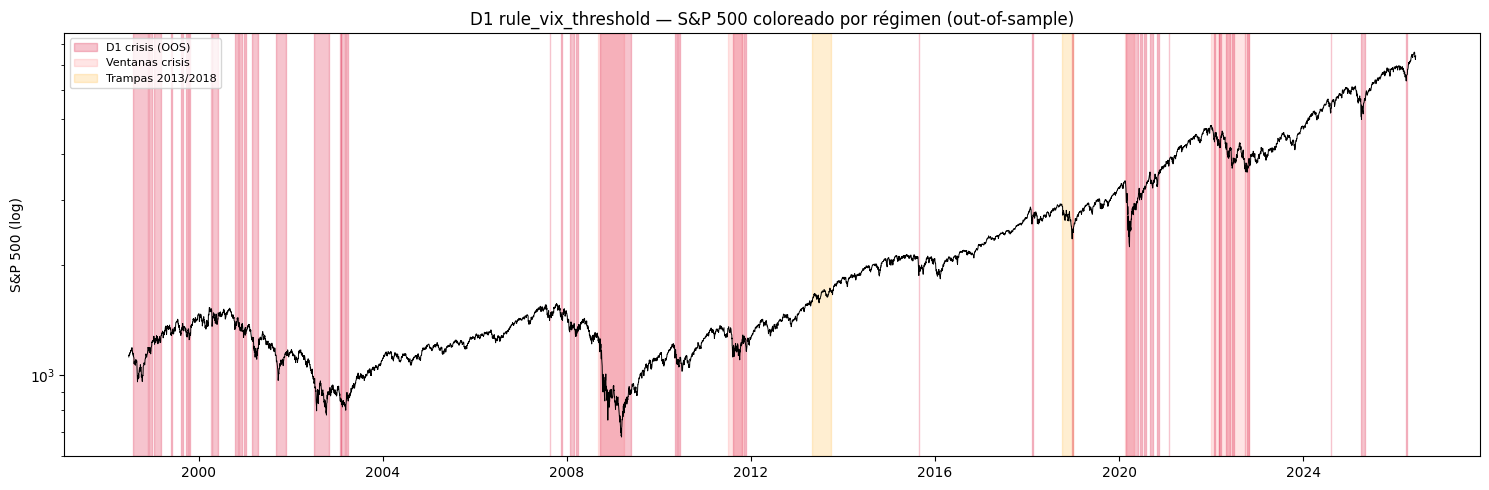

In [7]:
spx = raw['SP500'].reindex(panel.index)
is_crisis = (panel['state'] == det0.crisis_state)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.index, spx, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
# Sombrear días OOS en crisis
ymin, ymax = ax.get_ylim()
ax.fill_between(panel.index, ymin, ymax, where=is_crisis.values, color='crimson',
                alpha=0.25, step='mid', zorder=1, label='D1: crisis (OOS)')
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18, zorder=0)
handles = [Patch(color='crimson', alpha=0.25, label='D1 crisis (OOS)'),
           Patch(color='red', alpha=0.10, label='Ventanas crisis'),
           Patch(color='orange', alpha=0.18, label='Trampas 2013/2018')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title('D1 rule_vix_threshold — S&P 500 coloreado por régimen (out-of-sample)')
fig.tight_layout(); fig.savefig(RESULTS / 'd1_regime_sp500.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Probabilidad / serie de crisis y timeline de regímenes

Arriba: `p_crisis` OOS (one-hot para una regla dura → 0/1) junto al VIX z y sus umbrales. Abajo: timeline de régimen (banda continua roja = crisis).

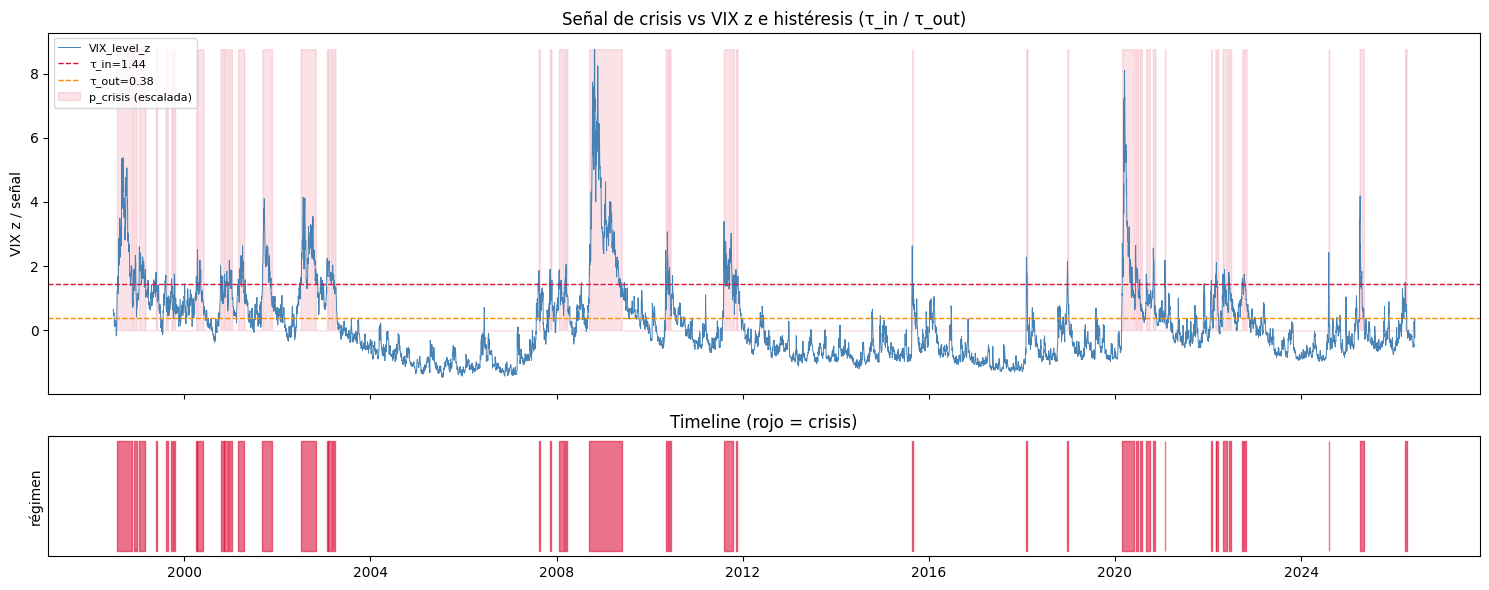

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
vz = X['VIX_level_z'].reindex(panel.index)
ax1.plot(vz.index, vz, color='steelblue', lw=0.7, label='VIX_level_z')
ax1.axhline(det0._tau_in, color='crimson', ls='--', lw=1, label=f'τ_in={det0._tau_in:.2f}')
ax1.axhline(det0._tau_out, color='darkorange', ls='--', lw=1, label=f'τ_out={det0._tau_out:.2f}')
ax1.fill_between(panel.index, 0, panel['p_crisis'].values * vz.max(),
                 color='crimson', alpha=0.12, step='mid', label='p_crisis (escalada)')
ax1.set_ylabel('VIX z / señal'); ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Señal de crisis vs VIX z e histéresis (τ_in / τ_out)')
ax2.fill_between(panel.index, 0, 1, where=is_crisis.values, color='crimson', alpha=0.6, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo = crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd1_prob_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Verificación explícita contra crisis y trampas

Cobertura (% de días marcados crisis) en cada ventana de crisis conocida y en cada trampa (2013 taper tantrum, Q4 2018). Para crisis: cuanto más alto mejor. Para trampas: cuanto más bajo mejor (especificidad).

In [9]:
states_oos = panel['state']
cov = ev.crisis_coverage(states_oos, det0.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det0.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno) ===')
for k, v in cov.items():
    flag = 'sin OOS' if (v != v) else ('OK' if v >= 0.5 else 'BAJA')
    print(f'  {k:16s}: {v:.2%}  [{flag}]' if v == v else f'  {k:16s}:   NaN  [{flag}]')
print('\n=== ACTIVACIÓN EN TRAMPAS (bajo = bueno; el HMM gaussiano falla aquí) ===')
for k, v in fa.items():
    print(f'  {k:16s}: {v:.2%}' if v == v else f'  {k:16s}:   NaN')
print(f'\nfalse_alarm_rate global (fuera de crisis): {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f}  |  duración media régimen: {res.mean_regime_duration:.1f} días')

=== COBERTURA EN CRISIS (alto = bueno) ===
  GFC_2008        : 93.84%  [OK]
  EuroDebt_2011   : 63.53%  [OK]
  COVID_2020      : 90.00%  [OK]
  Inflation_2022  : 34.93%  [BAJA]

=== ACTIVACIÓN EN TRAMPAS (bajo = bueno; el HMM gaussiano falla aquí) ===
  TaperTantrum_2013: 0.00%
  Selloff_Q4_2018 : 6.35%

false_alarm_rate global (fuera de crisis): 69.74%
switching_rate: 0.0132  |  duración media régimen: 75.2 días


In [10]:
capto_2013 = (fa.get('TaperTantrum_2013', float('nan')) or 0) > 0.05
capto_2018 = (fa.get('Selloff_Q4_2018', float('nan')) or 0) > 0.05
crisis_ok = {k: (v is not None and v == v and v >= 0.5) for k, v in cov.items()}
print('Crisis cubiertas (≥50% días crisis):')
for k, ok in crisis_ok.items():
    print(f'   {k:16s}: {"SI" if ok else ("sin OOS" if cov[k] != cov[k] else "parcial")}')
print(f'\n¿Se activó en 2013 (taper)? {"SI" if capto_2013 else "no"}  '
      f'(act={fa.get("TaperTantrum_2013", float("nan")):.1%})')
print(f'¿Se activó en 2018 (Q4)?     {"SI" if capto_2018 else "no"}  '
      f'(act={fa.get("Selloff_Q4_2018", float("nan")):.1%})')
print('\nNota: en 2013/2018 "activarse" es señal DESEABLE de reactividad (fueron '
      'episodios reales de estrés) pero cuenta como falso positivo en el marco '
      'estricto, que solo considera crisis sistémicas a 2008/2011/2020/2022.')

Crisis cubiertas (≥50% días crisis):
   GFC_2008        : SI
   EuroDebt_2011   : SI
   COVID_2020      : SI
   Inflation_2022  : parcial

¿Se activó en 2013 (taper)? no  (act=0.0%)
¿Se activó en 2018 (Q4)?     SI  (act=6.3%)

Nota: en 2013/2018 "activarse" es señal DESEABLE de reactividad (fueron episodios reales de estrés) pero cuenta como falso positivo en el marco estricto, que solo considera crisis sistémicas a 2008/2011/2020/2022.


## 8. Conclusión y contraste con la hipótesis del CP2

La hipótesis del CHECKPOINT 2 para D1 era: *capta las 4 crisis y probablemente 2013/2018 que el HMM falló; falla en falsos positivos sin histéresis*. Los números de arriba (cobertura por crisis, activación en trampas, `false_alarm_rate`, `switching_rate`) confirman o matizan esa hipótesis. Detalle y discusión en `docs/memory/detectors/01_rule_vix_threshold.md`.